In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from collections import Counter
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence


In [29]:
PAD = 0
SOS = 1
EOS = 2
UNK = 3

In [ ]:
def tokenize(sentence):
    return sentence.lower().strip().split()


class Vocab:
    def __init__(self, max_size):
        self.max_size = max_size
        self.word2idx = {
            "<PAD>": PAD,
            "<SOS>": SOS,
            "<EOS>": EOS,
            "<UNK>": UNK
        }
        self.idx2word = {v: k for k, v in self.word2idx.items()}

    def build(self, sentences):
        counter = Counter()
        for sent in sentences:
            counter.update(sent)

        for word, _ in counter.most_common(self.max_size - len(self.word2idx)):
            idx = len(self.word2idx)
            self.word2idx[word] = idx
            self.idx2word[idx] = word

    def encode(self, sentence):
        return [
            self.word2idx.get(word, UNK)
            for word in sentence
        ]


In [31]:
def load_parallel_data(path, max_len=50):
    src_sentences = []
    tgt_sentences = []

    with open(path, encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split("\t")
            if len(parts) != 4:
                continue
            
            if(parts[-1][-1] == "."):
                tmp = parts[-1][:-1]
                parts = parts[:-1]
                parts.append(tmp)

            en = tokenize(parts[1])
            de = tokenize(parts[3])

            if len(en) > max_len or len(de) > max_len:
                continue

            en = list(reversed(en))

            src_sentences.append(en)
            tgt_sentences.append(de)

    return src_sentences, tgt_sentences


In [33]:
src_sents, tgt_sents = load_parallel_data("en_de_pairs.tsv")

src_vocab = Vocab(max_size=10000)
tgt_vocab = Vocab(max_size=10000)

src_vocab.build(src_sents)
tgt_vocab.build(tgt_sents)

In [34]:
src_sents[:5]

[['something.', 'try', "let's"],
 ['something.', 'try', "let's"],
 ['something.', 'try', "let's"],
 ['birthday!', "muiriel's", 'is', 'it', 'and', '18th', 'june', 'is', 'today'],
 ['birthday!', "muiriel's", 'is', 'it', 'and', '18th', 'june', 'is', 'today']]

In [ ]:
class TranslationDataset(Dataset):
    def __init__(self, src_sents, tgt_sents, src_vocab, tgt_vocab):
        self.src_sents = src_sents
        self.tgt_sents = tgt_sents
        self.src_vocab = src_vocab
        self.tgt_vocab = tgt_vocab

    def __len__(self):
        return len(self.src_sents)

    def __getitem__(self, idx):
        src = self.src_sents[idx]
        tgt = self.tgt_sents[idx]

        src_ids = self.src_vocab.encode(src) + [EOS]

        tgt_input = [SOS] + self.tgt_vocab.encode(tgt)
        tgt_output = self.tgt_vocab.encode(tgt) + [EOS]

        return {
            "src": torch.tensor(src_ids),
            "tgt_in": torch.tensor(tgt_input),
            "tgt_out": torch.tensor(tgt_output)
        }


In [ ]:
def collate_fn(batch):
    src = [item["src"] for item in batch]
    tgt_in = [item["tgt_in"] for item in batch]
    tgt_out = [item["tgt_out"] for item in batch]

    src = pad_sequence(src, batch_first=True, padding_value=PAD)
    tgt_in = pad_sequence(tgt_in, batch_first=True, padding_value=PAD)
    tgt_out = pad_sequence(tgt_out, batch_first=True, padding_value=PAD)

    return src, tgt_in, tgt_out


In [ ]:
dataset = TranslationDataset(src_sents, tgt_sents, src_vocab, tgt_vocab)

loader = DataLoader(
    dataset,
    batch_size=64,
    shuffle=True,
    collate_fn=collate_fn
)


In [38]:
src, tgt_in, tgt_out = next(iter(loader))
print(src, tgt_in, tgt_out)

tensor([[1171,  198,    5,  ...,    0,    0,    0],
        [2651,   21,   10,  ...,    0,    0,    0],
        [2328,   31,  692,  ...,    0,    0,    0],
        ...,
        [1449, 1019,   85,  ...,    0,    0,    0],
        [ 620,    4, 2838,  ...,    0,    0,    0],
        [ 200,  295,   77,  ...,    0,    0,    0]]) tensor([[   1,   66, 1871,  ...,    0,    0,    0],
        [   1,   25,    7,  ...,    0,    0,    0],
        [   1,    4,  250,  ...,    0,    0,    0],
        ...,
        [   1,   73,   11,  ...,    0,    0,    0],
        [   1, 1367,  246,  ...,    0,    0,    0],
        [   1,   66,  193,  ...,    0,    0,    0]]) tensor([[  66, 1871,  189,  ...,    0,    0,    0],
        [  25,    7,    9,  ...,    0,    0,    0],
        [   4,  250,    5,  ...,    0,    0,    0],
        ...,
        [  73,   11, 3017,  ...,    0,    0,    0],
        [1367,  246, 3238,  ...,    0,    0,    0],
        [  66,  193,   81,  ...,    0,    0,    0]])


In [39]:
print(src.shape, tgt_in.shape, tgt_out.shape)

torch.Size([64, 29]) torch.Size([64, 30]) torch.Size([64, 30])


In [ ]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, num_layers=1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD)
        self.lstm = nn.LSTM(
            emb_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )

    def forward(self, src):
        # src: [B, src_len]
        emb = self.embedding(src)           # [B, src_len, emb_dim]
        _, (h, c) = self.lstm(emb)
        return h, c


In [41]:
class Decoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, num_layers=1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD)
        self.lstm = nn.LSTM(
            emb_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, tgt_in, h, c):
        # tgt_in: [B, tgt_len]
        emb = self.embedding(tgt_in)        # [B, tgt_len, emb_dim]
        out, (h, c) = self.lstm(emb, (h, c))
        logits = self.fc(out)               # [B, tgt_len, vocab]
        return logits, h, c


In [42]:
EMB_DIM = 512
HIDDEN_DIM = 1024
NUM_LAYERS = 1


encoder = Encoder(
    vocab_size=len(src_vocab.word2idx),
    emb_dim=EMB_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS
)

decoder = Decoder(
    vocab_size=len(tgt_vocab.word2idx),
    emb_dim=EMB_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS
)


In [43]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
encoder.to(device)
decoder.to(device)

Decoder(
  (embedding): Embedding(10000, 512, padding_idx=0)
  (lstm): LSTM(512, 1024, batch_first=True)
  (fc): Linear(in_features=1024, out_features=10000, bias=True)
)

In [44]:
loss_fn = nn.CrossEntropyLoss(ignore_index=PAD)

def train_step(encoder, decoder, batch, optimizer):
    src, tgt_in, tgt_out = batch
    src = src.to(device)
    tgt_in = tgt_in.to(device)
    tgt_out = tgt_out.to(device)

    h, c = encoder(src)
    logits, _ , _ = decoder(tgt_in, h, c)

    loss = loss_fn(
        logits.view(-1, logits.size(-1)), # [B, seq len or T, V] → [B*T, V]
        tgt_out.view(-1) # [B, T]    → [B*T]
    )

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    return loss.item()


In [ ]:
optimizer = optim.Adam(
    list(encoder.parameters()) + list(decoder.parameters()),
    lr=1e-3
)

In [46]:
num_epochs = 15
losses = []
for epoch in range(num_epochs):
    encoder.train()
    decoder.train()

    total_loss = 0

    for batch in loader:
        loss = train_step(encoder, decoder, batch, optimizer)
        total_loss += loss


    print(f"Epoch {epoch}: {total_loss / len(loader):.4f}")

    losses.append(total_loss)


Epoch 0: 2.6039
Epoch 1: 1.6014
Epoch 2: 1.3168
Epoch 3: 1.1522
Epoch 4: 1.0437
Epoch 5: 0.9668
Epoch 6: 0.9127
Epoch 7: 0.8721
Epoch 8: 0.8435
Epoch 9: 0.8231
Epoch 10: 0.8048
Epoch 11: 0.7926
Epoch 12: 0.7829
Epoch 13: 0.7772
Epoch 14: 0.7722


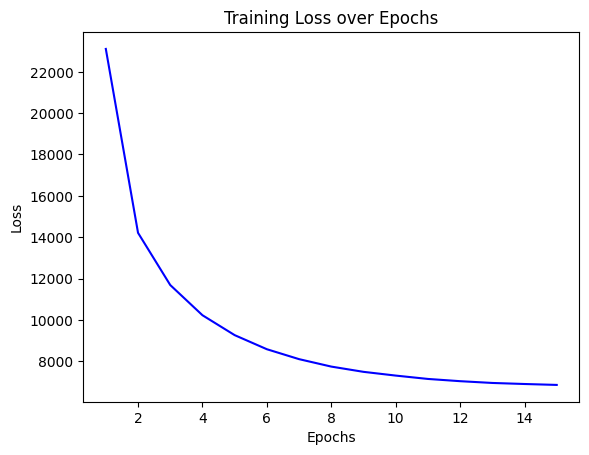

In [47]:
import matplotlib.pyplot as plt

plt.plot(list(range(1, num_epochs+1)), losses, color="b")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss over Epochs")
plt.show()

In [56]:
def decode_ids(ids, vocab):
    words = []
    for i in ids:
        if i == EOS:
            break
        if i in (PAD, SOS):
            continue
        words.append(vocab.idx2word.get(i, "<UNK>"))
    return " ".join(words)

import torch.nn.functional as F

def greedy_decode(encoder, decoder, src, max_len=50):
    encoder.eval()
    decoder.eval()

    with torch.no_grad():
        src = src.to(device)

        h, c = encoder(src)

        batch_size = src.size(0)
        # print(batch_size)
        ys = torch.full((batch_size, 1), SOS, dtype=torch.long, device=device)
        # print(f"starting ys is: {ys}")
        decoded = [[] for _ in range(batch_size)]

        for index in range(max_len):
            logits, _ , _ = decoder(ys, h, c)
            # print(f"logits for index {index+1} :{logits}")
            # print(f"logits shape :{logits.shape}")
            next_token = logits[:, -1].argmax(dim=-1)
            # print(f"Next Token: {next_token}")
            ys = torch.cat([ys, next_token.unsqueeze(1)], dim=1)
            # print(f"Updated ys: {ys}")
            for i in range(batch_size):
                decoded[i].append(next_token[i].item())
                # print(f"Updated Decoded: {decoded}")

        return decoded


In [57]:
src, tgt_in, tgt_out = next(iter(loader))

src.shape
src[0]

tensor([7249,   12,  601,   16,  387,    4,    2,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0])

In [58]:
src.shape

torch.Size([64, 28])

In [59]:
preds = greedy_decode(encoder, decoder, src)

for i in range(5):
    print("SRC :", decode_ids(src[i].tolist(), src_vocab))
    print("TGT :", decode_ids(tgt_out[i].tolist(), tgt_vocab))
    print("PRD :", decode_ids(preds[i], tgt_vocab))
    print("-" * 50)


SRC : passengers. of full was train the
TGT : der zug war voller fahrgäste
PRD : der zug war voller fahrgäste
--------------------------------------------------
SRC : cry. you make could tom
TGT : tom könnte sie zum weinen bringen
PRD : tom könnte sie weinen lassen
--------------------------------------------------
SRC : explanation. <UNK> your for you thank
TGT : danke für deine <UNK> erklärung
PRD : danke für deine <UNK>
--------------------------------------------------
SRC : food. of out running is tom
TGT : tom geht die <UNK> aus
PRD : tom geht es aus essen
--------------------------------------------------
SRC : life. his of rest the for him feed you and fish to man a teach day. a for him feed you and fish a man a give
TGT : gibt man einem menschen einen fisch, <UNK> man ihn für einen <UNK> lehrt man ihn aber das <UNK> <UNK> man ihn fürs ganze leben
PRD : gib einen mann zu ihm <UNK> du musst ihm einen mann und ein <UNK> seinen mahlzeiten <UNK> <UNK> <UNK> und <UNK> damit, dass si

In [60]:
def length_norm(score, length, alpha=0.7):
    return score / (length ** alpha)

def beam_search_decode(encoder, decoder, src, beam_size=3, max_len=50):
    encoder.eval()
    decoder.eval()

    with torch.no_grad():
        src = src.unsqueeze(0).to(device)
        h0, c0 = encoder(src)

        beams = [([SOS], 0.0, h0, c0)]
        completed = []

        for _ in range(max_len):
            new_beams = []

            for seq, score, h, c in beams:
                if seq[-1] == EOS:
                    completed.append((seq, score))
                    continue

                y = torch.tensor([[seq[-1]]], device=device)
                logits, h_new, c_new = decoder(y, h, c)
                log_probs = F.log_softmax(logits[:, -1], dim=-1)

                topk = torch.topk(log_probs, beam_size)

                for i in range(beam_size):
                    token = topk.indices[0][i].item()
                    token_score = topk.values[0][i].item()

                    new_beams.append(
                        (seq + [token], score + token_score, h_new, c_new)
                    )

            beams = sorted(new_beams, key=lambda x: x[1], reverse=True)[:beam_size]

            if not beams:
                break

        completed.extend([(seq, score) for seq, score, _, _ in beams])

        best_seq = max(
        completed,
        key=lambda x: length_norm(x[1], len(x[0]))
        )[0]

        return best_seq


In [61]:
src, tgt_in, tgt_out = next(iter(loader))

In [62]:
for i in range(5):
    greedy_pred = greedy_decode(encoder, decoder, src[i:i+1])[0]
    beam_pred = beam_search_decode(encoder, decoder, src[i], beam_size=3)

    print("SRC :", decode_ids(src[i].tolist(), src_vocab))
    print("TGT :", decode_ids(tgt_out[i].tolist(), tgt_vocab))
    print("GRD :", decode_ids(greedy_pred, tgt_vocab))
    print("BMS :", decode_ids(beam_pred, tgt_vocab))
    print("-" * 60)


SRC : defeat. of <UNK> the from victory snatched tom
TGT : tom hat die <UNK> niederlage doch noch in einen sieg verwandelt
GRD : tom <UNK> die <UNK> niederlage von der niederlage entfernt
BMS : tom <UNK> die <UNK> niederlage von der niederlage entfernt
------------------------------------------------------------
SRC : peace. in go
TGT : geht in <UNK>
GRD : geh in <UNK>
BMS : geh in <UNK>
------------------------------------------------------------
SRC : win. will you
TGT : ihr werdet gewinnen
GRD : du wirst siegen
BMS : du wirst siegen
------------------------------------------------------------
SRC : says. he what to attention more pay should you
TGT : du solltest mehr darauf <UNK> was er sagt
GRD : du solltest mehr tun, was er dir sagt
BMS : du solltest mehr tun, was er dir sagt
------------------------------------------------------------
SRC : journalist. a is boyfriend my
TGT : mein freund ist journalist
GRD : mein freund ist journalist
BMS : mein freund ist journalist
------------